# Data Understanding EDA

##  ----------GROUP QUANTUM THINKERS----------
| MEMBER's NAME | ENROLLMENT.No |
|------|--------|
| Kshitiz Kumar | 2502140035 |
| Aaditya Verma| 2502140130 |
| Kushal | 2502140037   |

In [ ]:
# %pip install pandas
%pip install numpy jinja2 matplotlib seaborn 




In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Car Sales.xlsx - car_data.csv")   # ya Excel ho to read_excel()

# First look
df.head()

# Shape
df.shape

# Columns
df.columns

# Data types
df.info()

# Summary stats
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   git push origin mainCar_id  23906 non-null  object
 1   Date                        23906 non-null  object
 2   Customer Name               23905 non-null  object
 3   Gender                      23906 non-null  object
 4   Annual Income               23906 non-null  int64 
 5   Dealer_Name                 23906 non-null  object
 6   Company                     23906 non-null  object
 7   Model                       23906 non-null  object
 8   Engine                      23906 non-null  object
 9   Transmission                23906 non-null  object
 10  Color                       23906 non-null  object
 11  Price ($)                   23906 non-null  int64 
 12  Dealer_No                   23906 non-null  object
 13  Body Style                  23906 non-null  ob

,Annual Income,Price ($),Phone
count,2.390600e+04,23906.000000,2.390600e+04
mean,8.308403e+05,28090.247846,7.497741e+06
std,7.200064e+05,14788.687608,8.674920e+05
min,1.008000e+04,1200.000000,6.000101e+06
25%,3.860000e+05,18001.000000,6.746495e+06
50%,7.350000e+05,23000.000000,7.496198e+06
75%,1.175750e+06,34000.000000,8.248146e+06
max,1.120000e+07,85800.000000,8.999579e+06


## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.facecolor'] = '#F8FAFC'
plt.rcParams['axes.facecolor'] = '#F8FAFC'
plt.rcParams['font.family'] = 'sans-serif'

COLORS = ['#2563EB','#7C3AED','#DB2777','#EA580C','#16A34A','#0891B2','#CA8A04']
ACCENT = '#1E293B'
print("✅ Libraries imported successfully")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries imported successfully


In [3]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   git push origin mainCar_id  23906 non-null  object
 1   Date                        23906 non-null  object
 2   Customer Name               23905 non-null  object
 3   Gender                      23906 non-null  object
 4   Annual Income               23906 non-null  int64 
 5   Dealer_Name                 23906 non-null  object
 6   Company                     23906 non-null  object
 7   Model                       23906 non-null  object
 8   Engine                      23906 non-null  object
 9   Transmission                23906 non-null  object
 10  Color                       23906 non-null  object
 11  Price ($)                   23906 non-null  int64 
 12  Dealer_No                   23906 non-null  object
 13  Body Style                  23906 non-null  ob

In [4]:
# Quick statistical summary
df.describe()

,Annual Income,Price ($),Phone
count,2.390600e+04,23906.000000,2.390600e+04
mean,8.308403e+05,28090.247846,7.497741e+06
std,7.200064e+05,14788.687608,8.674920e+05
min,1.008000e+04,1200.000000,6.000101e+06
25%,3.860000e+05,18001.000000,6.746495e+06
50%,7.350000e+05,23000.000000,7.496198e+06
75%,1.175750e+06,34000.000000,8.248146e+06
max,1.120000e+07,85800.000000,8.999579e+06


## 3. Data Wrangling

### 3.1 Missing Values

In [10]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found")
print()

# Fill the 1 missing Customer Name
df['Customer Name'].fillna('Unknown', inplace=True)
print(f"After fill — missing in 'Customer Name': {df['Customer Name'].isnull().sum()}")

Missing values per column:
Customer Name    1
dtype: int64

After fill — missing in 'Customer Name': 1


### 3.2 Duplicate Removal

In [11]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df = df.drop_duplicates()
print(f"✅ Dataset shape after dedup: {df.shape}")

Duplicate rows found: 0
✅ Dataset shape after dedup: (23906, 16)


### 3.3 Data Type Corrections

In [12]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("Date dtype:", df['Date'].dtype)

# Fix hidden non-breaking space character in Engine column
df['Engine'] = df['Engine'].str.replace('\xa0', ' ').str.strip()
print("\nUnique engine types after cleaning:")
print(df['Engine'].value_counts())

Date dtype: datetime64[us]

Unique engine types after cleaning:
Engine
DoubleÂ Overhead Camshaft    12571
Overhead Camshaft            11335
Name: count, dtype: int64


### 3.4 Filtering & Transformations

In [14]:
# Verify numeric columns
df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')
df['Annual Income'] = pd.to_numeric(df['Annual Income'], errors='coerce')

# Price range check
print(f"Price range: ${df['Price ($)'].min():,.0f} — ${df['Price ($)'].max():,.0f}")
print(f"Income range: ${df['Annual Income'].min():,.0f} — ${df['Annual Income'].max():,.0f}")

# Flag extreme outliers (for reference, not dropped)
outliers = df[df['Annual Income'] > 5_000_000]
print(f"\nHigh income outliers (>$5M): {len(outliers)} records ({len(outliers)/len(df)*100:.2f}% of data)")

Price range: $1,200 — $85,800
Income range: $10,080 — $11,200,000

High income outliers (>$5M): 37 records (0.15% of data)


### 3.5 Summary After Wrangling

In [15]:
print("=" * 50)
print("DATASET SUMMARY AFTER WRANGLING")
print("=" * 50)
print(f"Total Records     : {len(df):,}")
print(f"Total Features    : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print(f"Date Range        : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Unique Brands     : {df['Company'].nunique()}")
print(f"Unique Dealers    : {df['Dealer_Name'].nunique()}")
print(f"Regions           : {df['Dealer_Region'].nunique()}")
print(f"Total Revenue     : ${df['Price ($)'].sum():,.0f}")
print("=" * 50)

DATASET SUMMARY AFTER WRANGLING
Total Records     : 23,906
Total Features    : 16
Missing Values    : 1
Duplicate Rows    : 0
Date Range        : 2022-01-02 → 2023-12-31
Unique Brands     : 30
Unique Dealers    : 28
Regions           : 7
Total Revenue     : $671,525,465


## 4. Exploratory Data Analysis (EDA)

### 4.1 Sales by Brand

In [4]:
brand_sales = df['Company'].value_counts()
print("Top 10 brands by units sold:")
print(brand_sales.head(10).to_string())

Top 10 brands by units sold:
Company
Chevrolet     1819
Dodge         1671
Ford          1614
Volkswagen    1333
Mercedes-B    1285
Mitsubishi    1277
Chrysler      1120
Oldsmobile    1111
Toyota        1110
Nissan         886


### 4.2 Average Price by Brand (Top 10)

In [5]:
avg_price_brand = df.groupby('Company')['Price ($)'].mean().sort_values(ascending=False)
print("Top 10 brands by average price:")
print(avg_price_brand.head(10).apply(lambda x: f'${x:,.0f}').to_string())

Top 10 brands by average price:
Company
Cadillac      $40,972
Saab          $36,516
Lexus         $34,025
Buick         $33,634
Oldsmobile    $31,894
Lincoln       $31,407
Saturn        $31,093
Toyota        $29,513
Plymouth      $29,405
Pontiac       $29,358


### 4.3 Gender & Demographic Analysis

In [6]:
print("Gender distribution:")
print(df['Gender'].value_counts())
print()
print(f"Male share  : {df['Gender'].value_counts(normalize=True)['Male']*100:.1f}%")
print(f"Female share: {df['Gender'].value_counts(normalize=True)['Female']*100:.1f}%")
print()
print("Average Annual Income by Gender:")
print(df.groupby('Gender')['Annual Income'].mean().apply(lambda x: f'${x:,.0f}'))

Gender distribution:
Gender
Male      18798
Female     5108
Name: count, dtype: int64

Male share  : 78.6%
Female share: 21.4%

Average Annual Income by Gender:
Gender
Female    $755,973
Male      $851,184
Name: Annual Income, dtype: object


### 4.4 Body Style & Transmission

In [7]:
print("Body Style distribution:")
print(df['Body Style'].value_counts())
print()
print("Transmission distribution:")
print(df['Transmission'].value_counts())
print()
print("Avg price by body style:")
print(df.groupby('Body Style')['Price ($)'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

Body Style distribution:
Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

Transmission distribution:
Transmission
Auto      12571
Manual    11335
Name: count, dtype: int64

Avg price by body style:
Body Style
Sedan        $29,833
Hardtop      $29,151
Passenger    $28,942
Hatchback    $27,127
SUV          $26,768
Name: Price ($), dtype: object


### 4.5 Regional Performance

In [8]:
region_stats = df.groupby('Dealer_Region').agg(
    Units_Sold=('Price ($)', 'count'),
    Total_Revenue=('Price ($)', 'sum'),
    Avg_Price=('Price ($)', 'mean')
).sort_values('Total_Revenue', ascending=False)

region_stats['Total_Revenue'] = region_stats['Total_Revenue'].apply(lambda x: f'${x:,.0f}')
region_stats['Avg_Price'] = region_stats['Avg_Price'].apply(lambda x: f'${x:,.0f}')
print(region_stats.to_string())

               Units_Sold Total_Revenue Avg_Price
Dealer_Region                                    
Austin               4135  $117,192,531   $28,342
Janesville           3821  $106,351,234   $27,833
Scottsdale           3433   $95,969,374   $27,955
Aurora               3130   $88,687,382   $28,335
Greenville           3128   $88,149,602   $28,181
Pasco                3131   $88,040,714   $28,119
Middletown           3128   $87,134,628   $27,856


### 4.6 Correlation Analysis

In [9]:
corr = df['Annual Income'].corr(df['Price ($)'])
print(f"Pearson Correlation — Annual Income vs Price: {corr:.4f}")
print()
print("Interpretation:")
if abs(corr) < 0.1:
    print("  → Very weak / negligible correlation")
elif abs(corr) < 0.3:
    print("  → Weak correlation")
elif abs(corr) < 0.5:
    print("  → Moderate correlation")
else:
    print("  → Strong correlation")

Pearson Correlation — Annual Income vs Price: 0.0121

Interpretation:
  → Very weak / negligible correlation


### 4.7 Color Preferences

In [10]:
print("Car color distribution:")
print(df['Color'].value_counts())
print()
print("Avg price by color:")
print(df.groupby('Color')['Price ($)'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

Car color distribution:
Color
Pale White    11256
Black          7857
Red            4793
Name: count, dtype: int64

Avg price by color:
Color
Red           $28,736
Black         $28,565
Pale White    $27,484
Name: Price ($), dtype: object


# 🚗 Car Sales Analysis — Part 3: Visualizations, Insights & Recommendations
**Dataset:** Car_Sales_xlsx_-_car_data.csv  
**Records:** 23,906 transactions | **Features:** 16 columns


## 5. Visualizations

### Fig 1 — Bar Chart: Top 10 Companies by Sales Volume

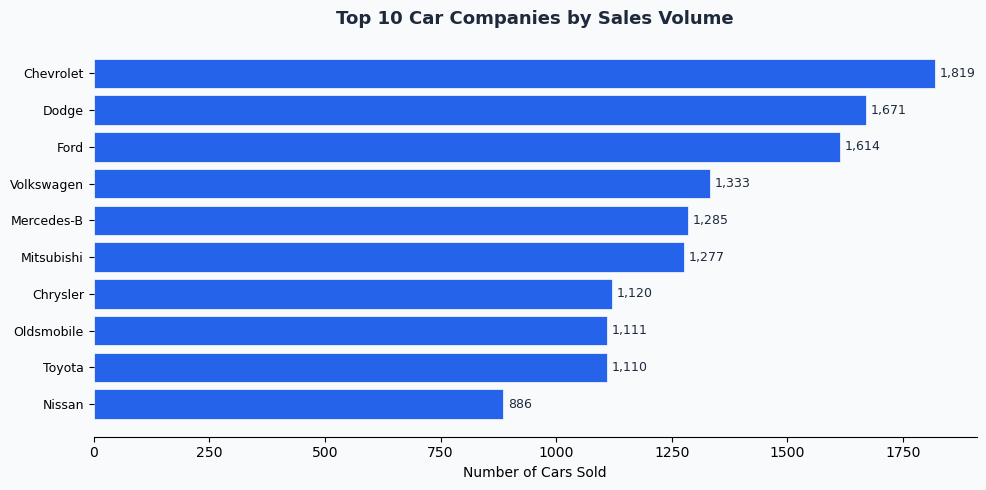

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
top10 = df['Company'].value_counts().head(10)
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=COLORS[0], edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, color=ACCENT)
ax.set_xlabel('Number of Cars Sold', fontsize=10)
ax.set_title('Top 10 Car Companies by Sales Volume', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

### Fig 2 — Pie Chart: Sales by Body Style

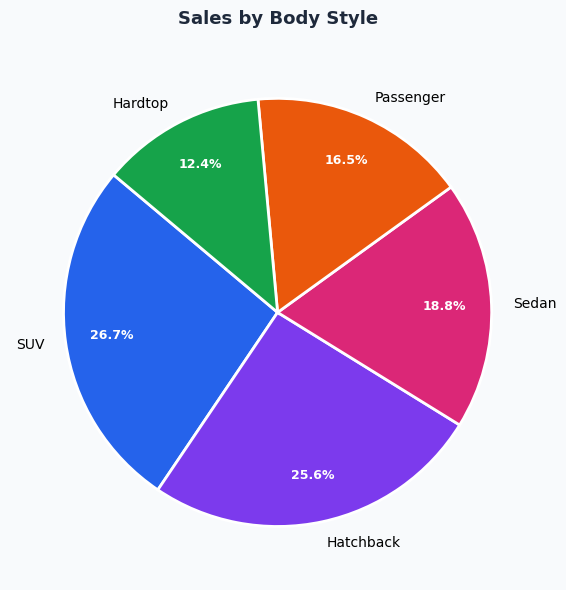

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
body = df['Body Style'].value_counts()
wedges, texts, autotexts = ax.pie(
    body.values, labels=body.index, autopct='%1.1f%%',
    colors=COLORS[:len(body)], startangle=140, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(9); t.set_color('white'); t.set_fontweight('bold')
ax.set_title('Sales by Body Style', fontsize=13, fontweight='bold', color=ACCENT, pad=15)
plt.tight_layout()
plt.show()

### Fig 3 — Histogram: Distribution of Car Prices

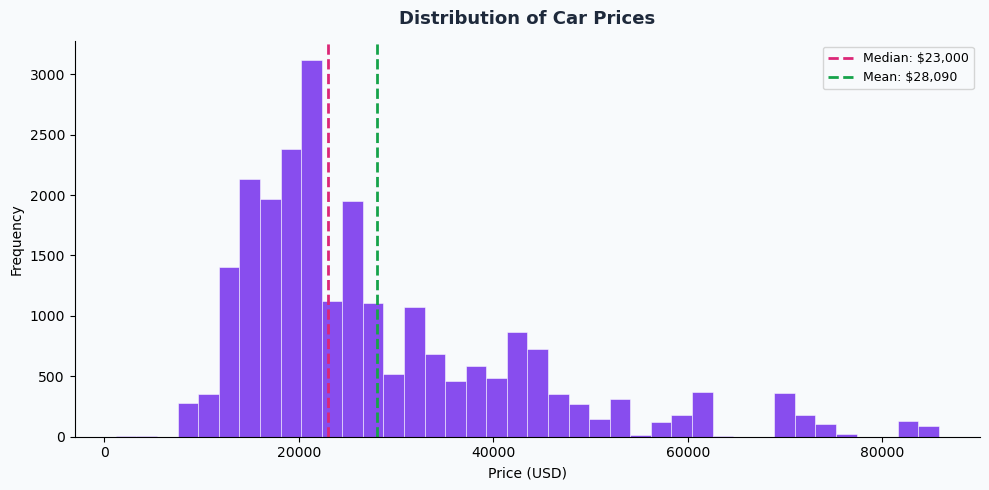

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Price ($)'].dropna(), bins=40, color=COLORS[1], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(df['Price ($)'].median(), color=COLORS[2], linewidth=2, linestyle='--',
           label=f'Median: ${df["Price ($)"].median():,.0f}')
ax.axvline(df['Price ($)'].mean(), color=COLORS[4], linewidth=2, linestyle='--',
           label=f'Mean: ${df["Price ($)"].mean():,.0f}')
ax.set_xlabel('Price (USD)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_title('Distribution of Car Prices', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Fig 4 — Scatter Plot: Annual Income vs Car Price (by Gender)

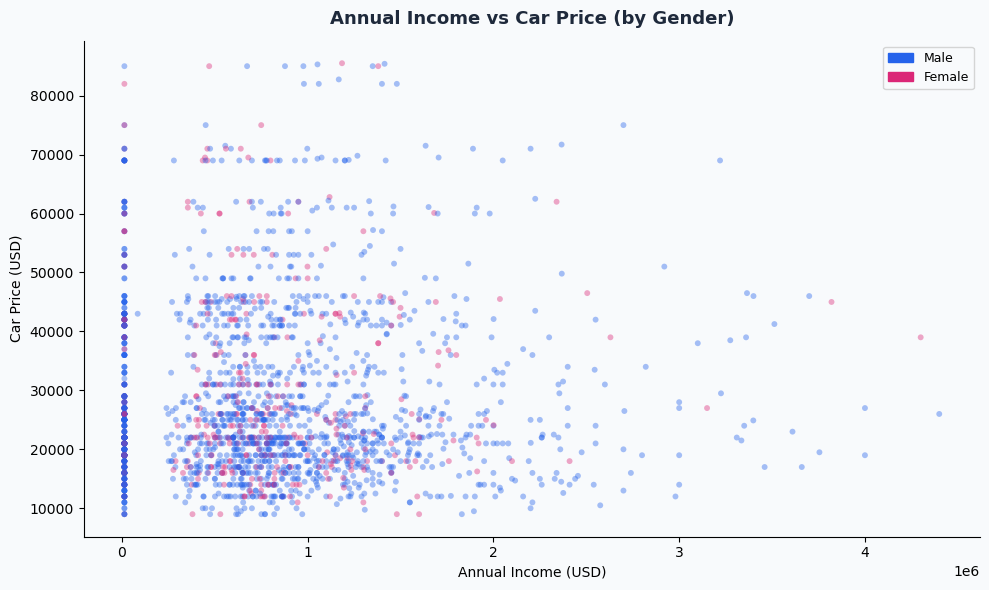

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df[df['Annual Income'] < 5_000_000].sample(2000, random_state=42)
colors_gender = sample['Gender'].map({'Male': COLORS[0], 'Female': COLORS[2]})
ax.scatter(sample['Annual Income'], sample['Price ($)'], c=colors_gender, alpha=0.4, s=18, edgecolors='none')
patches = [mpatches.Patch(color=COLORS[0], label='Male'), mpatches.Patch(color=COLORS[2], label='Female')]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Annual Income (USD)', fontsize=10)
ax.set_ylabel('Car Price (USD)', fontsize=10)
ax.set_title('Annual Income vs Car Price (by Gender)', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Fig 5 — Bar Chart: Average Car Price by Dealer Region

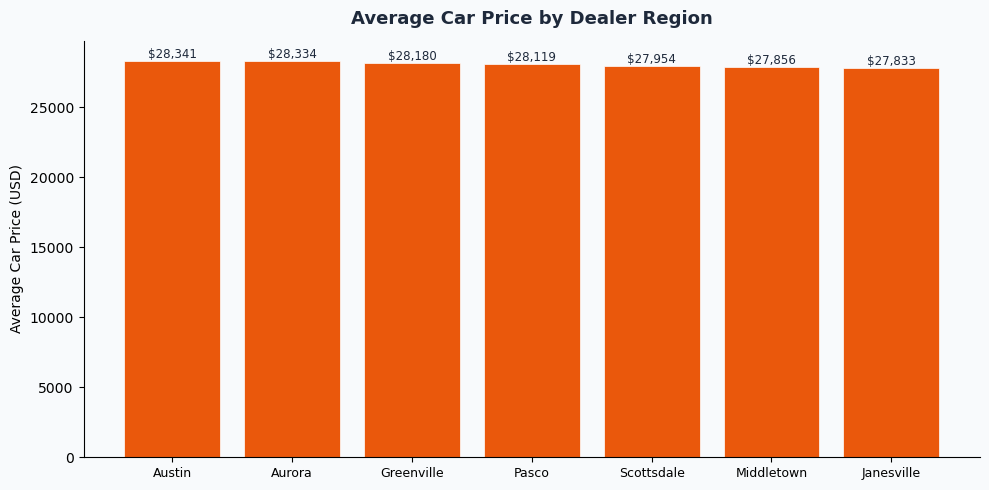

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
region_price = df.groupby('Dealer_Region')['Price ($)'].mean().sort_values(ascending=False)
bars = ax.bar(region_price.index, region_price.values, color=COLORS[3], edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'${int(bar.get_height()):,}', ha='center', fontsize=8.5, color=ACCENT)
ax.set_ylabel('Average Car Price (USD)', fontsize=10)
ax.set_title('Average Car Price by Dealer Region', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

### Fig 6 — Grouped Bar: Transmission Preference by Gender

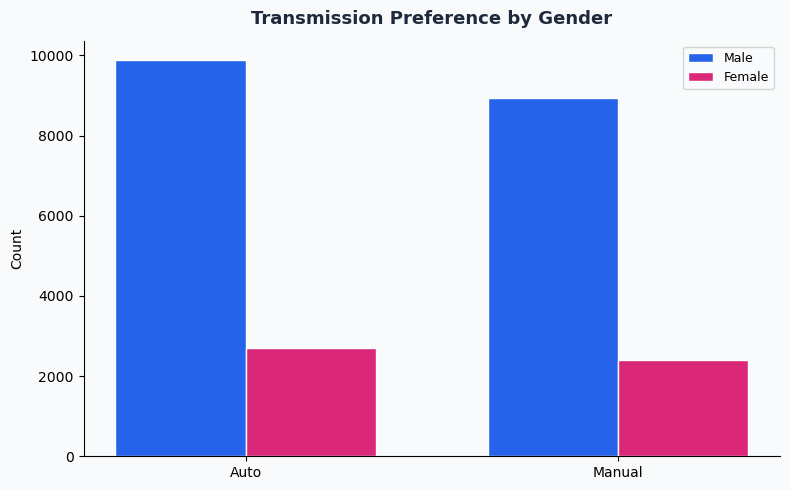

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
cross = df.groupby(['Transmission','Gender']).size().unstack()
x = np.arange(len(cross.index))
w = 0.35
ax.bar(x - w/2, cross['Male'],   w, label='Male',   color=COLORS[0], edgecolor='white')
ax.bar(x + w/2, cross['Female'], w, label='Female', color=COLORS[2], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cross.index)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Transmission Preference by Gender', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### Fig 7 — Bonus: Top 10 Companies by Average Revenue per Unit

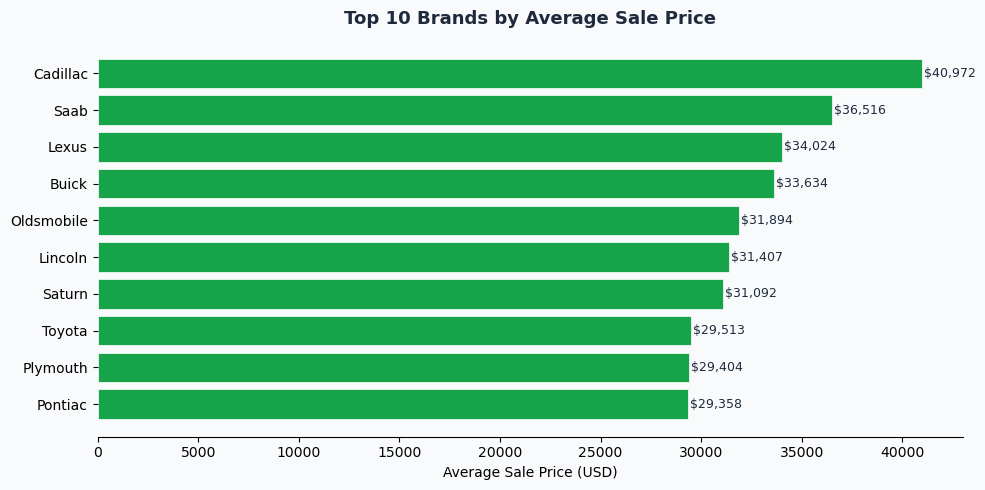

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
avg_rev = df.groupby('Company')['Price ($)'].mean().sort_values(ascending=False).head(10)
bars = ax.barh(avg_rev.index[::-1], avg_rev.values[::-1], color=COLORS[4], edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
            f'${int(bar.get_width()):,}', va='center', fontsize=9, color=ACCENT)
ax.set_xlabel('Average Sale Price (USD)', fontsize=10)
ax.set_title('Top 10 Brands by Average Sale Price', fontsize=13, fontweight='bold', color=ACCENT, pad=12)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Key Business Insights

| # | Insight | Detail |
|---|---------|--------|
| 1 | **Chevrolet leads by volume** | 1,819 units — highest of 30 brands |
| 2 | **Cadillac leads by price** | Avg $40,972 vs overall avg $28,090 |
| 3 | **SUVs & Hatchbacks dominate** | Together >52% of all sales |
| 4 | **Income ≠ Price** | Correlation r = 0.012 — financing is key |
| 5 | **78.6% male buyers** | Female segment is largely untapped |
| 6 | **Austin is top region** | 4,135 units — 8% more than #2 Janesville |
| 7 | **Pale White dominates** | 47.1% of cars sold — very limited palette |
| 8 | **Manual still relevant** | 47.4% of sales — unusual vs global trends |
| 9 | **Total revenue = $671.5M** | Across 23,906 transactions |
| 10 | **Price is right-skewed** | Median ($23K) << Mean ($28K) = luxury tail |

## 7. Business Recommendations

1. **Target Female Buyers** — With only 21.4% female customers, a focused marketing campaign could unlock a major growth segment.

2. **Invest in Luxury Brands** — Cadillac, Saab, and Lexus generate 45–50% more revenue per unit. Expanding their inventory increases margin without increasing volume pressure.

3. **Expand Color Options** — Only 3 colors available. Adding silver, grey, and blue could capture preference-driven buyers being lost to competitors.

4. **Prioritize SUV & Hatchback Inventory** — These two body styles account for 52%+ of sales. Ensure top availability across all regions, especially Austin.

5. **Strengthen Financing Offers** — The near-zero income-price correlation proves buyers across all income brackets purchase similarly priced cars, likely through financing. Promote low-APR deals.

6. **Leverage Austin, Develop Middletown as Premium Hub** — Austin = volume leader; Middletown = highest avg price. Tailor strategies per region.

7. **Maintain Manual Transmission Stock** — At 47.4%, manual is far from obsolete in this market. Do not phase it out prematurely.

---
*Notebook generated from 23,906 records · Python (pandas, matplotlib, numpy)*